In [87]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [4]:
df=pd.read_csv(r"D:\citez_leveing\global_cost_of_living_crisis_2026.csv")
pd.set_option('display.max_columns', None)
df

,rank,city,country,region,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index,avg_monthly_net_salary_usd,monthly_rent_1br_city_center_usd,monthly_rent_1br_outside_center_usd,petrol_price_usd_per_liter,annual_inflation_rate_2025_pct,population_city_millions,cost_crisis_tier,crisis_label,oil_shock_exposure,rent_to_salary_ratio_pct,data_year,baseline_city
0,1,Zurich,Switzerland,Western Europe,118.5,70.6,97.1,115.4,121.0,164.4,7200,2471,1750,1.92,1.2,0.45,1,Affluent – High Cost,Low,70.8,2026,"New York, USA (index=100)"
1,2,Geneva,Switzerland,Western Europe,116.5,65.1,93.6,114.3,121.8,158.5,7984,2279,1600,1.92,1.2,0.62,1,Affluent – High Cost,Low,70.2,2026,"New York, USA (index=100)"
2,3,Basel,Switzerland,Western Europe,112.4,49.6,84.4,110.4,114.9,183.7,6800,1736,1200,1.92,1.2,0.18,1,Affluent – High Cost,Low,69.1,2026,"New York, USA (index=100)"
3,4,Lausanne,Switzerland,Western Europe,111.5,55.0,86.3,108.9,116.2,163.7,6500,1925,1350,1.92,1.2,0.14,1,Affluent – High Cost,Low,70.1,2026,"New York, USA (index=100)"
4,5,Bern,Switzerland,Western Europe,110.0,46.8,81.8,107.3,110.2,174.4,6600,1638,1100,1.92,1.2,0.14,1,Affluent – High Cost,Low,67.2,2026,"New York, USA (index=100)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,76,Dhaka,Bangladesh,South Asia,27.0,10.0,20.0,24.0,25.0,50.0,350,350,180,1.03,10.5,22.00,5,Severe Affordability Crisis,High,51.4,2026,"New York, USA (index=100)"
76,77,Karachi,Pakistan,South Asia,27.0,8.0,19.0,23.0,25.0,48.0,350,280,145,0.90,28.5,16.90,5,Severe Inflation Crisis,High,51.8,2026,"New York, USA (index=100)"
77,78,Cairo,Egypt,North Africa,26.0,7.0,18.5,22.0,24.0,42.0,165,245,130,0.42,28.0,21.70,5,Hyperinflation Crisis,High,53.1,2026,"New York, USA (index=100)"
78,79,Lahore,Pakistan,South Asia,26.0,7.0,18.0,22.0,24.0,46.0,320,245,125,0.90,28.5,13.90,5,Severe Inflation Crisis,High,51.0,2026,"New York, USA (index=100)"


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 22 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   rank                                 80 non-null     int64  
 1   city                                 80 non-null     str    
 2   country                              80 non-null     str    
 3   region                               80 non-null     str    
 4   cost_of_living_index                 80 non-null     float64
 5   rent_index                           80 non-null     float64
 6   cost_of_living_plus_rent_index       80 non-null     float64
 7   groceries_index                      80 non-null     float64
 8   restaurant_price_index               80 non-null     float64
 9   local_purchasing_power_index         80 non-null     float64
 10  avg_monthly_net_salary_usd           80 non-null     int64  
 11  monthly_rent_1br_city_center_usd     80 non-n

In [7]:
df.shape

(80, 22)

In [8]:
df.describe()

,rank,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index,avg_monthly_net_salary_usd,monthly_rent_1br_city_center_usd,monthly_rent_1br_outside_center_usd,petrol_price_usd_per_liter,annual_inflation_rate_2025_pct,population_city_millions,cost_crisis_tier,rent_to_salary_ratio_pct,data_year
count,80.0000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.00000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.0
mean,40.5000,62.616250,36.105000,51.130000,59.903750,62.802500,97.236250,2865.362500,1263.76250,814.500000,1.293625,8.281250,6.337125,2.925000,61.471250,2026.0
std,23.2379,25.137412,21.735504,22.554241,26.550413,28.532331,40.349838,2125.141546,760.82073,535.924376,0.474273,18.557936,7.755835,1.270652,5.945048,0.0
min,1.0000,24.000000,7.000000,17.500000,21.000000,23.000000,35.000000,165.000000,245.00000,125.000000,0.400000,0.900000,0.140000,1.000000,51.000000,2026.0
25%,20.7500,38.000000,17.000000,29.750000,34.000000,37.750000,58.000000,737.500000,595.00000,327.500000,0.930000,2.700000,0.970000,2.000000,57.100000,2026.0
50%,40.5000,65.500000,32.750000,52.100000,63.250000,55.750000,96.000000,3000.000000,1146.50000,735.000000,1.180000,3.100000,2.675000,3.000000,62.250000,2026.0
75%,60.2500,78.825000,52.450000,68.275000,78.000000,88.450000,128.475000,4250.000000,1835.75000,1200.000000,1.757500,5.000000,9.557500,4.000000,67.200000,2026.0
max,80.0000,118.500000,100.000000,100.000000,115.400000,121.800000,183.700000,7984.000000,3500.00000,2200.000000,2.450000,150.000000,34.500000,5.000000,71.200000,2026.0


In [13]:
df['rank'].describe()

count    80.0000
mean     40.5000
std      23.2379
min       1.0000
25%      20.7500
50%      40.5000
75%      60.2500
max      80.0000
Name: rank, dtype: float64

In [9]:
df.isnull().sum()

rank                                   0
city                                   0
country                                0
region                                 0
cost_of_living_index                   0
rent_index                             0
cost_of_living_plus_rent_index         0
groceries_index                        0
restaurant_price_index                 0
local_purchasing_power_index           0
avg_monthly_net_salary_usd             0
monthly_rent_1br_city_center_usd       0
monthly_rent_1br_outside_center_usd    0
petrol_price_usd_per_liter             0
annual_inflation_rate_2025_pct         0
population_city_millions               0
cost_crisis_tier                       0
crisis_label                           0
oil_shock_exposure                     0
rent_to_salary_ratio_pct               0
data_year                              0
baseline_city                          0
dtype: int64

In [10]:
df.dropna(how='all',inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['rank', 'city', 'country', 'region', 'cost_of_living_index',
       'rent_index', 'cost_of_living_plus_rent_index', 'groceries_index',
       'restaurant_price_index', 'local_purchasing_power_index',
       'avg_monthly_net_salary_usd', 'monthly_rent_1br_city_center_usd',
       'monthly_rent_1br_outside_center_usd', 'petrol_price_usd_per_liter',
       'annual_inflation_rate_2025_pct', 'population_city_millions',
       'cost_crisis_tier', 'crisis_label', 'oil_shock_exposure',
       'rent_to_salary_ratio_pct', 'data_year', 'baseline_city'],
      dtype='str')

In [182]:
df = df[df['country'] != 'Israel' ]

In [15]:
df.corr(numeric_only=True)['avg_monthly_net_salary_usd']

rank                                  -0.925508
cost_of_living_index                   0.951133
rent_index                             0.874839
cost_of_living_plus_rent_index         0.948284
groceries_index                        0.955800
restaurant_price_index                 0.911995
local_purchasing_power_index           0.938232
avg_monthly_net_salary_usd             1.000000
monthly_rent_1br_city_center_usd       0.874848
monthly_rent_1br_outside_center_usd    0.893309
petrol_price_usd_per_liter             0.439014
annual_inflation_rate_2025_pct        -0.337005
population_city_millions              -0.513763
cost_crisis_tier                      -0.873202
rent_to_salary_ratio_pct               0.911995
data_year                                   NaN
Name: avg_monthly_net_salary_usd, dtype: float64

In [16]:
df

,rank,city,country,region,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index,avg_monthly_net_salary_usd,monthly_rent_1br_city_center_usd,monthly_rent_1br_outside_center_usd,petrol_price_usd_per_liter,annual_inflation_rate_2025_pct,population_city_millions,cost_crisis_tier,crisis_label,oil_shock_exposure,rent_to_salary_ratio_pct,data_year,baseline_city
0,1,Zurich,Switzerland,Western Europe,118.5,70.6,97.1,115.4,121.0,164.4,7200,2471,1750,1.92,1.2,0.45,1,Affluent – High Cost,Low,70.8,2026,"New York, USA (index=100)"
1,2,Geneva,Switzerland,Western Europe,116.5,65.1,93.6,114.3,121.8,158.5,7984,2279,1600,1.92,1.2,0.62,1,Affluent – High Cost,Low,70.2,2026,"New York, USA (index=100)"
2,3,Basel,Switzerland,Western Europe,112.4,49.6,84.4,110.4,114.9,183.7,6800,1736,1200,1.92,1.2,0.18,1,Affluent – High Cost,Low,69.1,2026,"New York, USA (index=100)"
3,4,Lausanne,Switzerland,Western Europe,111.5,55.0,86.3,108.9,116.2,163.7,6500,1925,1350,1.92,1.2,0.14,1,Affluent – High Cost,Low,70.1,2026,"New York, USA (index=100)"
4,5,Bern,Switzerland,Western Europe,110.0,46.8,81.8,107.3,110.2,174.4,6600,1638,1100,1.92,1.2,0.14,1,Affluent – High Cost,Low,67.2,2026,"New York, USA (index=100)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,76,Dhaka,Bangladesh,South Asia,27.0,10.0,20.0,24.0,25.0,50.0,350,350,180,1.03,10.5,22.00,5,Severe Affordability Crisis,High,51.4,2026,"New York, USA (index=100)"
76,77,Karachi,Pakistan,South Asia,27.0,8.0,19.0,23.0,25.0,48.0,350,280,145,0.90,28.5,16.90,5,Severe Inflation Crisis,High,51.8,2026,"New York, USA (index=100)"
77,78,Cairo,Egypt,North Africa,26.0,7.0,18.5,22.0,24.0,42.0,165,245,130,0.42,28.0,21.70,5,Hyperinflation Crisis,High,53.1,2026,"New York, USA (index=100)"
78,79,Lahore,Pakistan,South Asia,26.0,7.0,18.0,22.0,24.0,46.0,320,245,125,0.90,28.5,13.90,5,Severe Inflation Crisis,High,51.0,2026,"New York, USA (index=100)"


 
top_cost_living _country

In [206]:
df = df[df['country'] != 'Israel' ]

In [207]:
top_cost_living_country = df.groupby('country')['cost_of_living_index'].mean().sort_values(ascending=False).head(10)

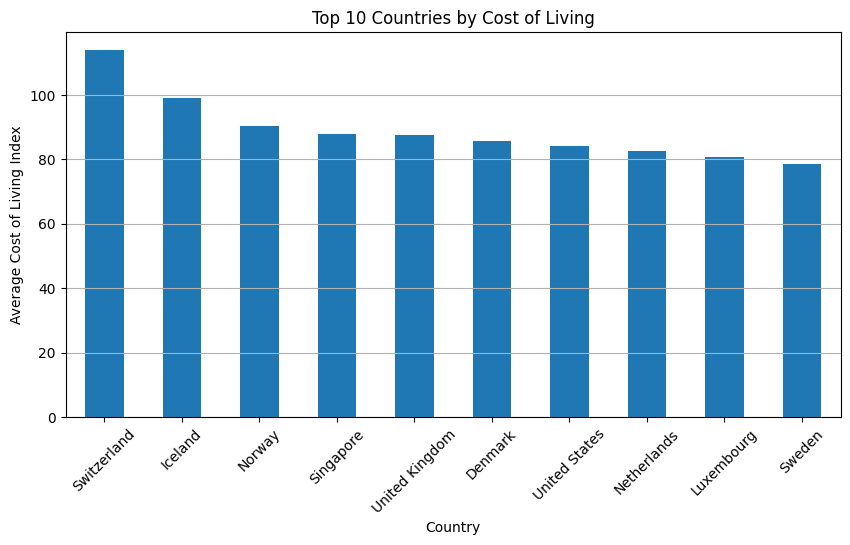

In [208]:
import matplotlib.pyplot as plt

top_cost_living_country = df.groupby('country')['cost_of_living_index'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_cost_living_country.plot(kind='bar')

plt.title("Top 10 Countries by Cost of Living")
plt.xlabel("Country")
plt.ylabel("Average Cost of Living Index")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()




top country in avg_monthly_net_salary_usd

In [19]:
df.groupby('country')['avg_monthly_net_salary_usd'].mean().sort_values(ascending=False).head(10)

country
Switzerland       7016.8
Luxembourg        5500.0
United States     5460.0
Singapore         5060.0
Norway            4800.0
Qatar             4500.0
United Kingdom    4400.0
Ireland           4200.0
Denmark           4200.0
Iceland           4120.0
Name: avg_monthly_net_salary_usd, dtype: float64

most country,cites that 'oil_shock_exposure

In [203]:
df = df[df['country'] != 'Israel' ]

In [204]:
heat_data = df[df["oil_shock_exposure"] == "High"] \
.sort_values("cost_of_living_index", ascending=False) \
.head(10) \
.set_index("city")[["cost_of_living_index", "avg_monthly_net_salary_usd"]]

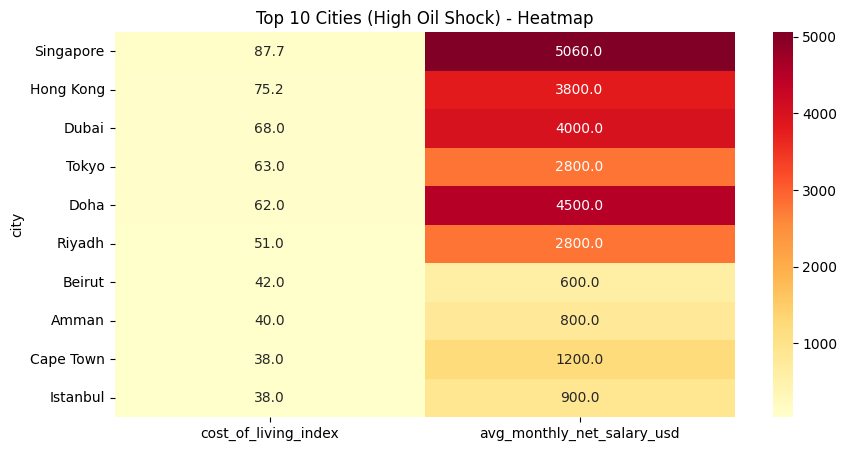

In [214]:


plt.figure(figsize=(10,5))

sns.heatmap(
    heat_data,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Top 10 Cities (High Oil Shock) - Heatmap")
plt.show()

In [27]:
df[["cost_of_living_index", "avg_monthly_net_salary_usd"]].corr()

,cost_of_living_index,avg_monthly_net_salary_usd
cost_of_living_index,1.000000,0.951133
avg_monthly_net_salary_usd,0.951133,1.000000


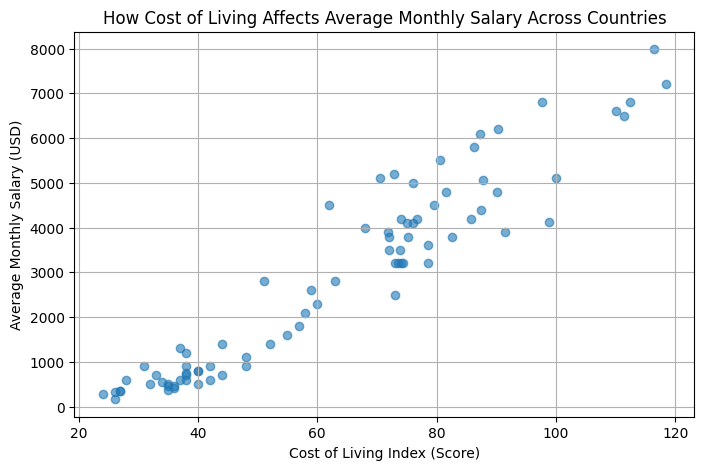

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df["cost_of_living_index"],
    df["avg_monthly_net_salary_usd"],
    alpha=0.6
)

plt.title("How Cost of Living Affects Average Monthly Salary Across Countries")
plt.xlabel("Cost of Living Index (Score)")
plt.ylabel("Average Monthly Salary (USD)")

plt.grid(True)

plt.show()

What Drives Economic Crisis? A Comparison of Living Costs and Income Levels

In [ ]:
df['crisis_label']=df['crisis_label'].str.strip()
crisize_Data=df['crisis_label'].str.contains("high")

In [ ]:
df["crisis_label"] = df["crisis_label"].str.strip()


crisis_data = df[df["crisis_label"].str.contains("High")]
low_data = df[~df["crisis_label"].str.contains("High")]

cols = [
    "cost_of_living_index",
    "groceries_index",
    "rent_index",
    "petrol_price_usd_per_liter",
    "avg_monthly_net_salary_usd"
]

high_mean = crisis_data[cols].mean()
low_mean = low_data[cols].mean()


compare_df = pd.DataFrame({
    "High Crisis": high_mean,
    "Low Crisis": low_mean
})



In [57]:
compare_df

,High Crisis,Low Crisis
cost_of_living_index,81.348718,44.797561
groceries_index,79.764103,41.012195
rent_index,53.446154,19.609756
petrol_price_usd_per_liter,1.436923,1.157317
avg_monthly_net_salary_usd,4481.128205,1328.414634


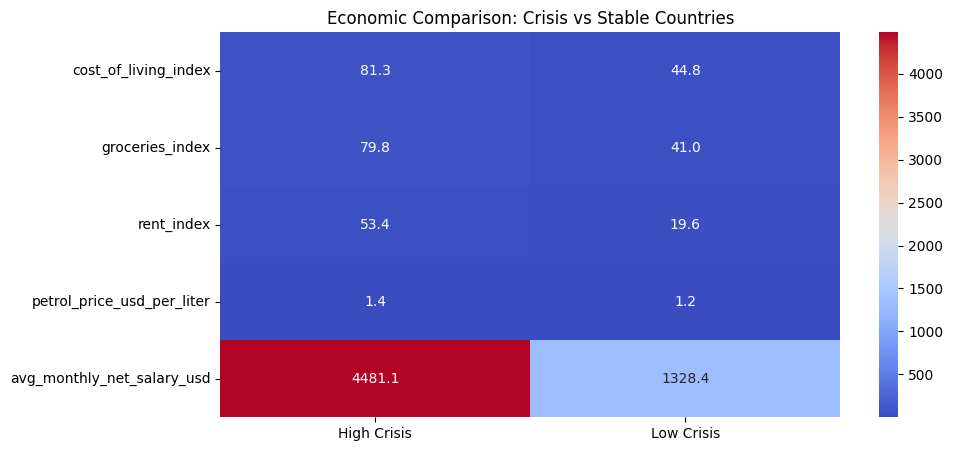

In [61]:


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.heatmap(
    compare_df,
    annot=True,
    fmt=".1f",
    cmap="coolwarm"
)

plt.title("Economic Comparison: Crisis vs Stable Countries")
plt.show()

In [67]:
df['population_city_millions'].dtype

dtype('float64')

Smaller population countries tend to have higher income and higher living costs, while larger population countries tend to have lower income and lower costs.

In [71]:


df["pop_category"] = np.where(
    df["population_city_millions"] >= df["population_city_millions"].median(),
    "High Population",
    "Low Population"
)

In [70]:
df.groupby("pop_category")[["cost_of_living_index", "avg_monthly_net_salary_usd"]].mean()

,cost_of_living_index,avg_monthly_net_salary_usd
pop_category,,
High Population,50.8850,1900.625
Low Population,74.3475,3830.100


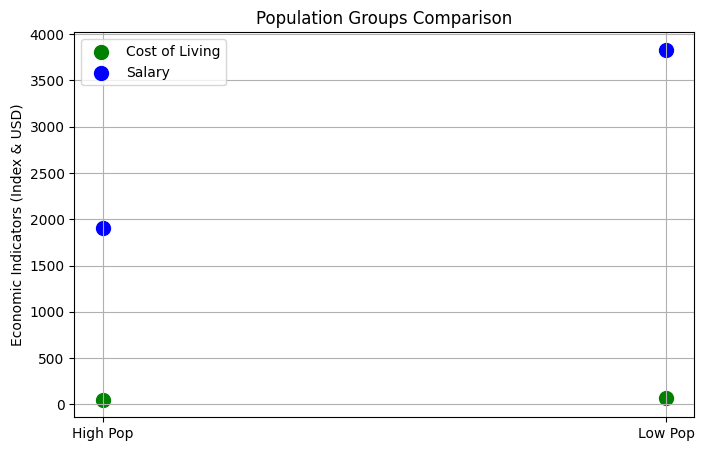

In [209]:
import matplotlib.pyplot as plt

groups = ["High Pop", "Low Pop"]

cost = [50.8850, 74.3475]
salary = [1900.625, 3830.100]

x = range(len(groups))

plt.figure(figsize=(8,5))


plt.scatter(x, cost, color="green", s=100, label="Cost of Living")

plt.scatter(x, salary, color="blue", s=100, label="Salary")

plt.xticks(x, groups)
plt.title("Population Groups Comparison")
plt.ylabel("Economic Indicators (Index & USD)")
plt.legend()
plt.grid(True)

plt.show()

In [81]:
df

,rank,city,country,region,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index,avg_monthly_net_salary_usd,monthly_rent_1br_city_center_usd,monthly_rent_1br_outside_center_usd,petrol_price_usd_per_liter,annual_inflation_rate_2025_pct,population_city_millions,cost_crisis_tier,crisis_label,oil_shock_exposure,rent_to_salary_ratio_pct,data_year,baseline_city,pop_category
0,1,Zurich,Switzerland,Western Europe,118.5,70.6,97.1,115.4,121.0,164.4,7200,2471,1750,1.92,1.2,0.45,1,Affluent – High Cost,Low,70.8,2026,"New York, USA (index=100)",Low Population
1,2,Geneva,Switzerland,Western Europe,116.5,65.1,93.6,114.3,121.8,158.5,7984,2279,1600,1.92,1.2,0.62,1,Affluent – High Cost,Low,70.2,2026,"New York, USA (index=100)",Low Population
2,3,Basel,Switzerland,Western Europe,112.4,49.6,84.4,110.4,114.9,183.7,6800,1736,1200,1.92,1.2,0.18,1,Affluent – High Cost,Low,69.1,2026,"New York, USA (index=100)",Low Population
3,4,Lausanne,Switzerland,Western Europe,111.5,55.0,86.3,108.9,116.2,163.7,6500,1925,1350,1.92,1.2,0.14,1,Affluent – High Cost,Low,70.1,2026,"New York, USA (index=100)",Low Population
4,5,Bern,Switzerland,Western Europe,110.0,46.8,81.8,107.3,110.2,174.4,6600,1638,1100,1.92,1.2,0.14,1,Affluent – High Cost,Low,67.2,2026,"New York, USA (index=100)",Low Population
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,76,Dhaka,Bangladesh,South Asia,27.0,10.0,20.0,24.0,25.0,50.0,350,350,180,1.03,10.5,22.00,5,Severe Affordability Crisis,High,51.4,2026,"New York, USA (index=100)",High Population
76,77,Karachi,Pakistan,South Asia,27.0,8.0,19.0,23.0,25.0,48.0,350,280,145,0.90,28.5,16.90,5,Severe Inflation Crisis,High,51.8,2026,"New York, USA (index=100)",High Population
77,78,Cairo,Egypt,North Africa,26.0,7.0,18.5,22.0,24.0,42.0,165,245,130,0.42,28.0,21.70,5,Hyperinflation Crisis,High,53.1,2026,"New York, USA (index=100)",High Population
78,79,Lahore,Pakistan,South Asia,26.0,7.0,18.0,22.0,24.0,46.0,320,245,125,0.90,28.5,13.90,5,Severe Inflation Crisis,High,51.0,2026,"New York, USA (index=100)",High Population


In [84]:
top = df.sort_values('population_city_millions',ascending=False)[['country','city','population_city_millions']] .head(10) 
top

,country,city,population_city_millions
63,Indonesia,Jakarta,34.5
74,India,Delhi,32.9
42,China,Shanghai,24.9
75,Bangladesh,Dhaka,22.0
44,China,Beijing,21.9
77,Egypt,Cairo,21.7
55,Mexico,Mexico City,21.6
71,India,Mumbai,20.7
76,Pakistan,Karachi,16.9
59,Turkey,Istanbul,15.8


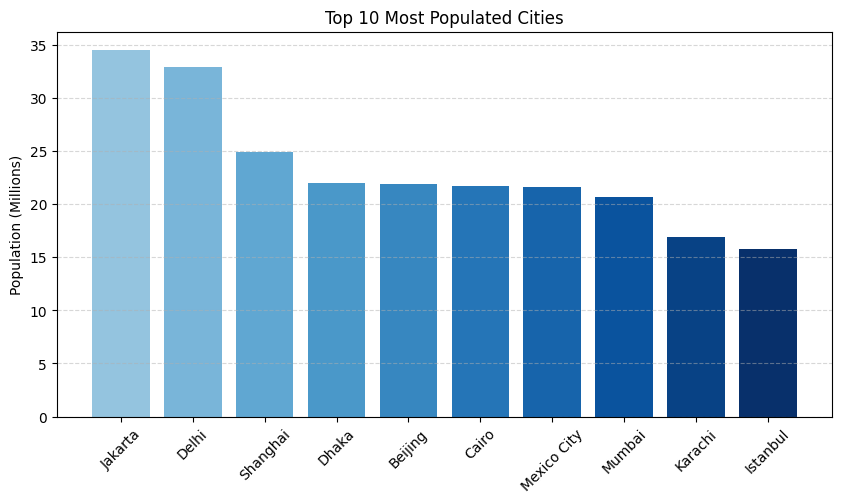

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
colors = plt.cm.Blues(np.linspace(0.4, 1, len(top)))
plt.bar(top["city"], top["population_city_millions"], color=colors) 
plt.xticks(rotation=45)
plt.title("Top 10 Most Populated Cities")
plt.ylabel("Population (Millions)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [108]:
df

,rank,city,country,region,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index,avg_monthly_net_salary_usd,monthly_rent_1br_city_center_usd,monthly_rent_1br_outside_center_usd,petrol_price_usd_per_liter,annual_inflation_rate_2025_pct,population_city_millions,cost_crisis_tier,crisis_label,oil_shock_exposure,rent_to_salary_ratio_pct,data_year,baseline_city,pop_category
0,1,Zurich,Switzerland,Western Europe,118.5,70.6,97.1,115.4,121.0,164.4,7200,2471,1750,1.92,1.2,0.45,1,Affluent – High Cost,Low,70.8,2026,"New York, USA (index=100)",Low Population
1,2,Geneva,Switzerland,Western Europe,116.5,65.1,93.6,114.3,121.8,158.5,7984,2279,1600,1.92,1.2,0.62,1,Affluent – High Cost,Low,70.2,2026,"New York, USA (index=100)",Low Population
2,3,Basel,Switzerland,Western Europe,112.4,49.6,84.4,110.4,114.9,183.7,6800,1736,1200,1.92,1.2,0.18,1,Affluent – High Cost,Low,69.1,2026,"New York, USA (index=100)",Low Population
3,4,Lausanne,Switzerland,Western Europe,111.5,55.0,86.3,108.9,116.2,163.7,6500,1925,1350,1.92,1.2,0.14,1,Affluent – High Cost,Low,70.1,2026,"New York, USA (index=100)",Low Population
4,5,Bern,Switzerland,Western Europe,110.0,46.8,81.8,107.3,110.2,174.4,6600,1638,1100,1.92,1.2,0.14,1,Affluent – High Cost,Low,67.2,2026,"New York, USA (index=100)",Low Population
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,76,Dhaka,Bangladesh,South Asia,27.0,10.0,20.0,24.0,25.0,50.0,350,350,180,1.03,10.5,22.00,5,Severe Affordability Crisis,High,51.4,2026,"New York, USA (index=100)",High Population
76,77,Karachi,Pakistan,South Asia,27.0,8.0,19.0,23.0,25.0,48.0,350,280,145,0.90,28.5,16.90,5,Severe Inflation Crisis,High,51.8,2026,"New York, USA (index=100)",High Population
77,78,Cairo,Egypt,North Africa,26.0,7.0,18.5,22.0,24.0,42.0,165,245,130,0.42,28.0,21.70,5,Hyperinflation Crisis,High,53.1,2026,"New York, USA (index=100)",High Population
78,79,Lahore,Pakistan,South Asia,26.0,7.0,18.0,22.0,24.0,46.0,320,245,125,0.90,28.5,13.90,5,Severe Inflation Crisis,High,51.0,2026,"New York, USA (index=100)",High Population


Countries with high oil shock exposure are more vulnerable to global oil price fluctuations, which may lead to higher inflation and increased cost of living in these regions.

In [199]:
df = df[df['country'] != 'Israel' ]

In [200]:
oil=df[df['oil_shock_exposure']=='High'] 
col=[
    "country",
    "city"
  
] 
top_cites_country=oil[col]
print(top_cites_country.to_string(index=False))

             country         city
           Singapore    Singapore
           Hong Kong    Hong Kong
United Arab Emirates        Dubai
               Japan        Tokyo
               Qatar         Doha
        Saudi Arabia       Riyadh
             Lebanon       Beirut
              Jordan        Amman
        South Africa    Cape Town
              Turkey     Istanbul
             Ukraine         Kyiv
        South Africa Johannesburg
               Ghana        Accra
               Kenya      Nairobi
             Nigeria        Lagos
           Sri Lanka      Colombo
           Argentina Buenos Aires
          Bangladesh        Dhaka
            Pakistan      Karachi
               Egypt        Cairo
            Pakistan       Lahore
               Nepal    Kathmandu


In [201]:

top5 = oil["country"].value_counts().head(5)
top5 

country
South Africa            2
Pakistan                2
Singapore               1
Hong Kong               1
United Arab Emirates    1
Name: count, dtype: int64

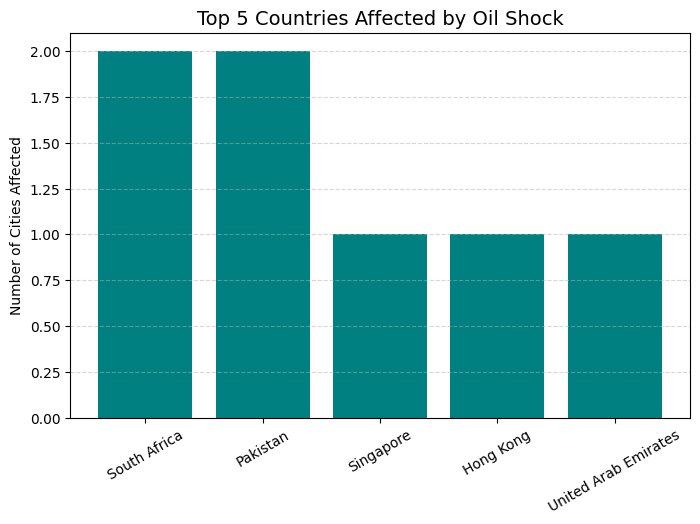

In [213]:


top5 = oil["country"].value_counts().head(5)

plt.figure(figsize=(8,5))

plt.bar(top5.index, top5.values, color="teal")  

plt.xticks(rotation=30)
plt.title("Top 5 Countries Affected by Oil Shock", fontsize=14)
plt.ylabel("Number of Cities Affected")  

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


This analysis shows the relationship between cost of living and local purchasing power across countries over time, helping identify economic strength and affordability trends.

In [ ]:
yearly_stats = df.groupby(["country", "data_year"])[[
    "cost_of_living_index",
    "local_purchasing_power_index"
]].mean().reset_index() .head(10)
yearly_stats

,country,data_year,cost_of_living_index,local_purchasing_power_index
0,Argentina,2026,34.00,38.00
1,Australia,2026,73.55,114.55
2,Austria,2026,73.90,133.50
3,Bangladesh,2026,27.00,50.00
4,Belgium,2026,73.50,128.00
5,Brazil,2026,44.00,52.00
6,Canada,2026,72.50,102.50
7,China,2026,59.00,81.00
8,Colombia,2026,35.00,48.00
9,Czech Republic,2026,57.00,95.00


In [ ]:
yearly_stats= df.groupby("country")[[
    "cost_of_living_index",
    "local_purchasing_power_index"
]].mean().reset_index() .head(10).reindex()


In [147]:
yearly_stats

,country,cost_of_living_index,local_purchasing_power_index
0,Argentina,34.00,38.00
1,Australia,73.55,114.55
2,Austria,73.90,133.50
3,Bangladesh,27.00,50.00
4,Belgium,73.50,128.00
5,Brazil,44.00,52.00
6,Canada,72.50,102.50
7,China,59.00,81.00
8,Colombia,35.00,48.00
9,Czech Republic,57.00,95.00


In [156]:
df['groceries_index'].corr(df['cost_of_living_index'])

np.float64(0.9860044531424939)

Food is one of the reasons for the high cost of living in countries. 

(Top 10 Countries by Groceries Index)

In [177]:
df = df[df['country'] != 'Israel' ]

In [180]:
topn_groceries = df.groupby('country')\
[['groceries_index','cost_of_living_index']].mean()\
    .sort_values('groceries_index', ascending=False)\
    .head(10) 
topn_groceries

,groceries_index,cost_of_living_index
country,,
Switzerland,111.26,113.78
Iceland,105.20,98.90
Norway,90.70,90.20
United States,87.90,84.18
New Zealand,80.00,74.00
Luxembourg,78.50,80.60
Denmark,78.30,85.70
France,77.90,78.60
Australia,77.60,73.55


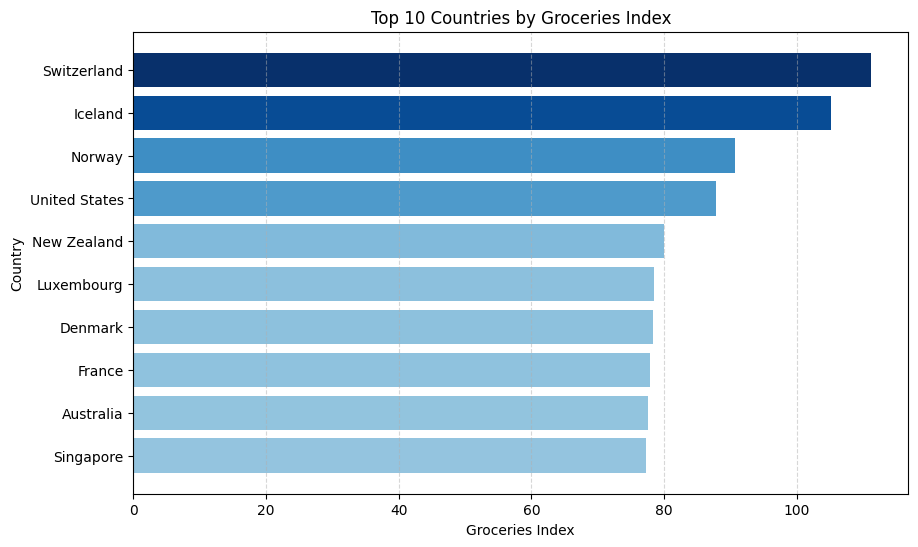

In [212]:


values = topn_groceries['groceries_index']

norm = (values - values.min()) / (values.max() - values.min())


colors = plt.cm.Blues(0.4 + 0.6 * norm)

plt.figure(figsize=(10,6))

plt.barh(topn_groceries.index, values, color=colors)

plt.xlabel("Groceries Index")
plt.ylabel("Country")
plt.title("Top 10 Countries by Groceries Index")

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

Top 10 Countries with Highest Inflation Rates (2025)

In [191]:
data = df.sort_values('annual_inflation_rate_2025_pct', ascending=False)\
    .head(10)[['country','annual_inflation_rate_2025_pct']] 
data

,country,annual_inflation_rate_2025_pct
70,Argentina,150.0
53,Lebanon,50.0
59,Turkey,47.0
68,Nigeria,34.0
76,Pakistan,28.5
78,Pakistan,28.5
77,Egypt,28.0
65,Ghana,18.0
62,Ukraine,14.5
69,Sri Lanka,14.0


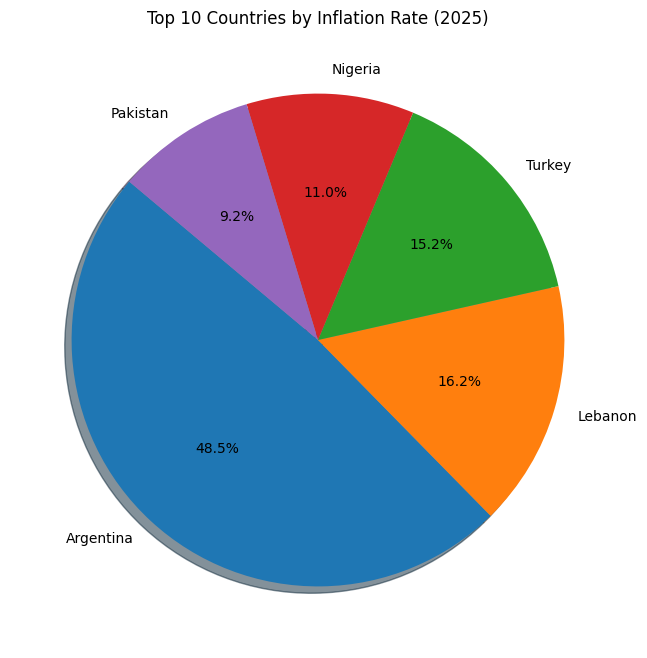

In [193]:
plt.figure(figsize=(8,8))

plt.pie(
    data['annual_inflation_rate_2025_pct'],
    labels=data['country'],
    autopct='%1.1f%%',
    startangle=140,
    shadow=True
)

plt.title("Top 10 Countries by Inflation Rate (2025)")

plt.show()

In [215]:
df.to_csv("cleaend_data1",index=False)